# Part B1 — Artificial Neural Network (ANN) on a structured dataset

**Dataset:** Breast Cancer Wisconsin (Diagnostic) dataset — 569 samples, 30
numeric features describing cell nuclei, binary label (malignant/benign).
This is the classic "structured/tabular classification" stand-in for the
churn/loan/diabetes datasets suggested in the task manual: same shape of
problem (numeric features -> binary label), built into scikit-learn so it
loads instantly with no external download.

**Why an ANN (and not a CNN/RNN) here:** the features have no spatial
structure (like pixels) or sequence structure (like a time series/text) —
they're just an unordered table of 30 measurements per patient. A fully
connected network is the right tool for that: every input can influence
every neuron in the next layer without any assumption about ordering.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1788431214.259102     718 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788431214.710557     718 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788431216.267302     718 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Preprocess: scale + train/test split

ANNs are sensitive to feature scale (a feature ranging 0-1000 would
dominate one ranging 0-1 purely because of magnitude, not importance), so
we standardize every feature to mean 0 / std 1 before training.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target  # 1 = benign, 0 = malignant
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Class balance (train): {np.bincount(y_train)}")

Train: (455, 30), Test: (114, 30)
Class balance (train): [170 285]


## Build and tune the ANN

Architecture choices and why:
- **Two hidden layers (32 -> 16 units)**: enough capacity to model
  non-linear interactions between the 30 features without being so large
  that it overfits a 455-row training set.
- **ReLU activation**: avoids the vanishing-gradient problem that sigmoid/
  tanh have in deeper networks, and is the standard default for hidden
  layers.
- **Dropout (0.3)**: randomly zeroes 30% of activations each training step,
  forcing the network not to rely too heavily on any single neuron —
  this is our main defense against overfitting on a small dataset.
- **Sigmoid output**: this is binary classification, so a single sigmoid
  neuron gives us a probability between 0 and 1.

In [3]:
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

ann = build_ann(X_train_s.shape[1])
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = ann.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0,
)
print(f"Training stopped after {len(history.history['loss'])} epochs (early stopping)")

Training stopped after 62 epochs (early stopping)


## Evaluate

In [5]:
test_loss, test_acc = ann.evaluate(X_test_s, y_test, verbose=0)
y_pred_prob = ann.predict(X_test_s, verbose=0).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

with open("ann_report.txt", "w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\n\n")
    f.write(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))

Test accuracy: 0.9649
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



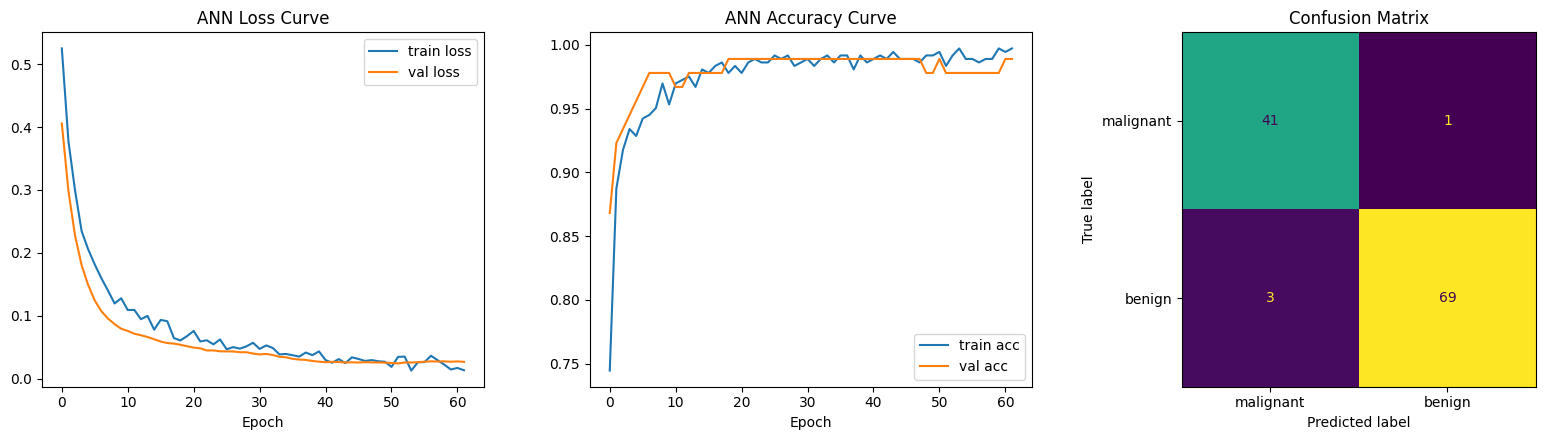

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("ANN Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train acc")
axes[1].plot(history.history["val_accuracy"], label="val acc")
axes[1].set_title("ANN Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["malignant", "benign"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("ann_training_curves.png", dpi=120)
plt.show()

## Summary

The ANN reaches high accuracy quickly on this dataset because the 30
features (radius, texture, concavity, etc.) are already strong, engineered
predictors of malignancy — the network mainly has to learn how to combine
them, not extract structure from raw signal. Dropout plus early stopping
kept validation loss from diverging from training loss, so the model isn't
overfitting despite the fairly small dataset (455 training rows).